In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("adm_data.csv")
df.columns = [c.strip() for c in df.columns]
df = df.drop(columns=["Serial No."])

df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [18]:
# Correlation Matrix
#Pearson correlation coefficient between every pair of features (ranges from -1 to1).

corr = df.corr()
corr

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
GRE Score,1.000000,0.835977,0.668976,0.612831,0.557555,0.833060,0.580391,0.802610
TOEFL Score,0.835977,1.000000,0.695590,0.657981,0.567721,0.828417,0.489858,0.791594
University Rating,0.668976,0.695590,1.000000,0.734523,0.660123,0.746479,0.447783,0.711250
SOP,0.612831,0.657981,0.734523,1.000000,0.729593,0.718144,0.444029,0.675732
LOR,0.557555,0.567721,0.660123,0.729593,1.000000,0.670211,0.396859,0.669889
CGPA,0.833060,0.828417,0.746479,0.718144,0.670211,1.000000,0.521654,0.873289
Research,0.580391,0.489858,0.447783,0.444029,0.396859,0.521654,1.000000,0.553202
Chance of Admit,0.802610,0.791594,0.711250,0.675732,0.669889,0.873289,0.553202,1.000000


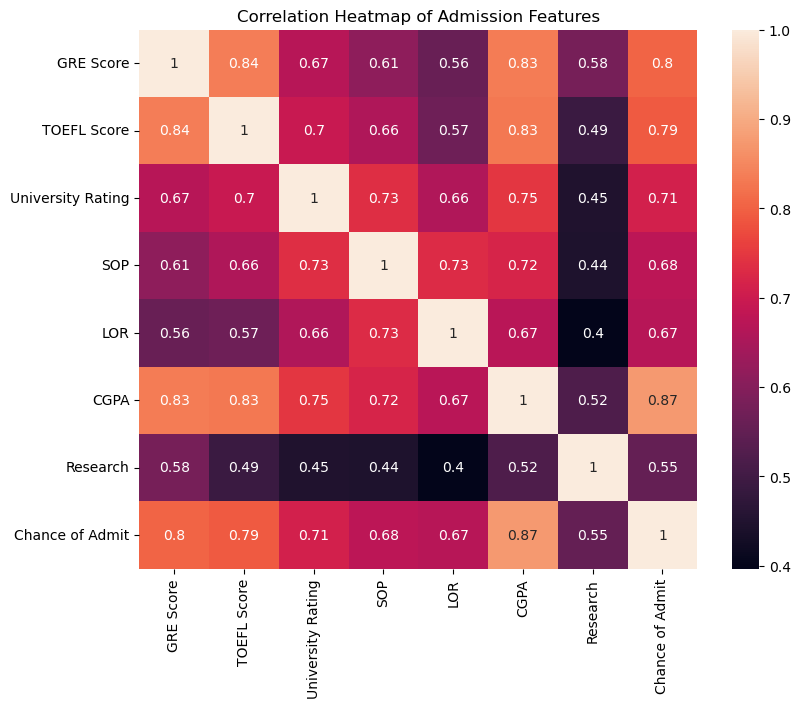

In [19]:
# Correlation Heatmap 

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr,
    annot=True,

)

plt.title("Correlation Heatmap of Admission Features")
plt.show()

In [20]:
#  Correlation With the Target Variable
# Which features are most strongly related to `Chance of Admit`?
target_corr = corr["Chance of Admit"].drop("Chance of Admit").sort_values(ascending=False)
target_corr

CGPA                 0.873289
GRE Score            0.802610
TOEFL Score          0.791594
University Rating    0.711250
SOP                  0.675732
LOR                  0.669889
Research             0.553202
Name: Chance of Admit, dtype: float64

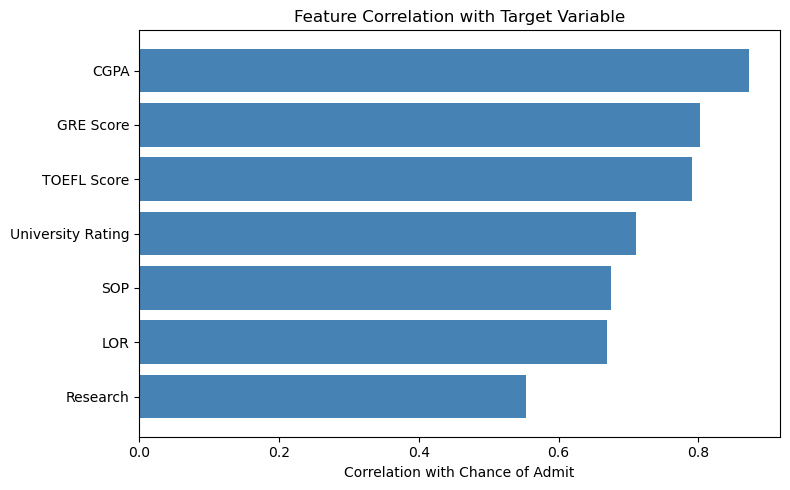

In [21]:
plt.figure(figsize=(8, 5))
plt.barh(target_corr.index, target_corr.values, color="steelblue")
plt.xlabel("Correlation with Chance of Admit")
plt.title("Feature Correlation with Target Variable")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [22]:
# Findings

#CGPA = has the highest correlation with Chance of Admit: 0.873.
#GRE Score: 0.803 and TOEFL Score: 0.792 also show strong positive relationships.
#University Rating: 0.711, SOP: 0.676, and LOR: 0.670 have moderate positive correlations.
#Research: 0.553 has the lowest correlation with Chance of Admit.
#Multicollinearity is observed between GRE–TOEFL (0.836), GRE–CGPA (0.833), and TOEFL–CGPA (0.828).

# Conclusion

''' The heatmap shows that CGPA, GRE Score, and TOEFL Score are the strongest predictors of admission chance. 
 However, their high inter-correlation indicates possible multicollinearity, which should be considered before model building.'''


' The heatmap shows that CGPA, GRE Score, and TOEFL Score are the strongest predictors of admission chance. \n However, their high inter-correlation indicates possible multicollinearity, which should be considered before model building.'